<a href="https://colab.research.google.com/github/MehrajSultana1919/product-retention-intelligence/blob/main/product_retention_analysis_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install kagglehub -q

import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("mkechinov/ecommerce-behavior-data-from-multi-category-store")

print(path)
print(os.listdir(path))

Using Colab cache for faster access to the 'ecommerce-behavior-data-from-multi-category-store' dataset.
/kaggle/input/ecommerce-behavior-data-from-multi-category-store
['2019-Nov.csv', '2019-Oct.csv']


In [12]:
oct_path = os.path.join(path, "2019-Oct.csv")
nov_path = os.path.join(path, "2019-Nov.csv")

oct_df = pd.read_csv(oct_path, nrows=100000)
nov_df = pd.read_csv(nov_path, nrows=100000)

df = pd.concat([oct_df, nov_df], ignore_index=True)

df.head()
print(df.shape)
df.head()

df.info()
df.isnull().sum()

df['event_time'] = pd.to_datetime(df['event_time'])
df['date'] = df['event_time'].dt.date

dau = df.groupby('date')['user_id'].nunique()

dau.head()

(200000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     200000 non-null  object 
 1   event_type     200000 non-null  object 
 2   product_id     200000 non-null  int64  
 3   category_id    200000 non-null  int64  
 4   category_code  133573 non-null  object 
 5   brand          169831 non-null  object 
 6   price          200000 non-null  float64
 7   user_id        200000 non-null  int64  
 8   user_session   200000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 13.7+ MB


,user_id
date,
2019-10-01,20384
2019-11-01,20778


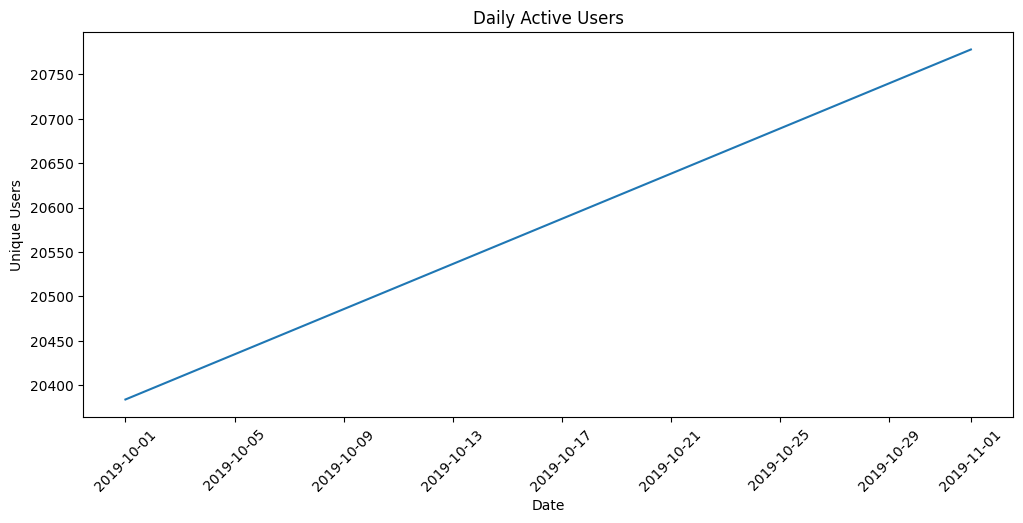

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(dau)
plt.title("Daily Active Users")
plt.xlabel("Date")
plt.ylabel("Unique Users")
plt.xticks(rotation=45)
plt.show()

In [15]:
# ===============================
# 1. DATA CLEANING + PREP
# ===============================

import pandas as pd
import numpy as np

df['event_time'] = pd.to_datetime(df['event_time'])
df['date'] = df['event_time'].dt.date
df['hour'] = df['event_time'].dt.hour
df['day_of_week'] = df['event_time'].dt.day_name()

df = df.drop_duplicates()

print("Rows:", df.shape[0])
print("Users:", df['user_id'].nunique())
print("Events:", df['event_type'].unique())
df.head()

Rows: 199956
Users: 40822
Events: ['view' 'purchase' 'cart']


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date,hour,day_of_week
0,2019-10-01 00:00:00+00:00,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c,2019-10-01,0,Tuesday
1,2019-10-01 00:00:00+00:00,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc,2019-10-01,0,Tuesday
2,2019-10-01 00:00:01+00:00,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8,2019-10-01,0,Tuesday
3,2019-10-01 00:00:01+00:00,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,2019-10-01,0,Tuesday
4,2019-10-01 00:00:04+00:00,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,2019-10-01,0,Tuesday


In [16]:
# ===============================
# 2. FUNNEL ANALYSIS
# ===============================

funnel = df.groupby('event_type')['user_id'].nunique().reset_index()
funnel.columns = ['event_type', 'unique_users']

funnel['conversion_from_previous_step'] = (
    funnel['unique_users'] / funnel['unique_users'].shift(1)
)

funnel['overall_conversion_from_view'] = (
    funnel['unique_users'] / funnel['unique_users'].max()
)

funnel

,event_type,unique_users,conversion_from_previous_step,overall_conversion_from_view
0,cart,1425,NaN,0.034912
1,purchase,2484,1.743158,0.060857
2,view,40817,16.431965,1.000000


In [17]:
# ===============================
# 3. USER FEATURE ENGINEERING
# ===============================

user_features = df.groupby('user_id').agg(
    total_events=('event_type', 'count'),
    active_days=('date', 'nunique'),
    unique_products=('product_id', 'nunique'),
    unique_categories=('category_id', 'nunique'),
    avg_price_viewed=('price', 'mean'),
    max_price_viewed=('price', 'max'),
    first_seen=('event_time', 'min'),
    last_seen=('event_time', 'max')
).reset_index()

event_counts = pd.crosstab(df['user_id'], df['event_type']).reset_index()

user_features = user_features.merge(event_counts, on='user_id', how='left')
user_features = user_features.fillna(0)

user_features['customer_lifetime_days'] = (
    user_features['last_seen'] - user_features['first_seen']
).dt.days + 1

user_features['events_per_day'] = (
    user_features['total_events'] / user_features['customer_lifetime_days']
)

user_features['cart_rate'] = user_features.get('cart', 0) / user_features['total_events']
user_features['purchase_rate'] = user_features.get('purchase', 0) / user_features['total_events']

user_features['purchased'] = (user_features.get('purchase', 0) > 0).astype(int)

user_features.head()

,user_id,total_events,active_days,unique_products,unique_categories,avg_price_viewed,max_price_viewed,first_seen,last_seen,cart,purchase,view,customer_lifetime_days,events_per_day,cart_rate,purchase_rate,purchased
0,275256741,1,1,1,1,1415.480000,1415.48,2019-11-01 02:23:03+00:00,2019-11-01 02:23:03+00:00,0,0,1,1,1.0,0.0,0.000000,0
1,295643776,8,1,4,2,189.946250,317.67,2019-11-01 03:12:38+00:00,2019-11-01 03:15:53+00:00,0,0,8,1,8.0,0.0,0.000000,0
2,306441847,2,1,1,1,164.710000,164.71,2019-10-01 01:32:09+00:00,2019-10-01 02:56:47+00:00,0,0,2,1,2.0,0.0,0.000000,0
3,356520186,6,1,1,1,33.450000,33.45,2019-11-01 03:39:27+00:00,2019-11-01 03:49:22+00:00,0,1,5,1,6.0,0.0,0.166667,1
4,362699320,7,1,7,3,127.041429,310.69,2019-10-01 03:05:49+00:00,2019-10-01 03:25:33+00:00,0,0,7,1,7.0,0.0,0.000000,0


In [18]:
# ===============================
# 4. PURCHASE PREDICTION MODEL
# ===============================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

features = [
    'total_events',
    'active_days',
    'unique_products',
    'unique_categories',
    'avg_price_viewed',
    'max_price_viewed',
    'customer_lifetime_days',
    'events_per_day',
    'cart_rate'
]

X = user_features[features]
y = user_features['purchased']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       0.99      0.81      0.89      7668
           1       0.22      0.83      0.35       497

    accuracy                           0.81      8165
   macro avg       0.60      0.82      0.62      8165
weighted avg       0.94      0.81      0.86      8165

ROC AUC: 0.911424073916635


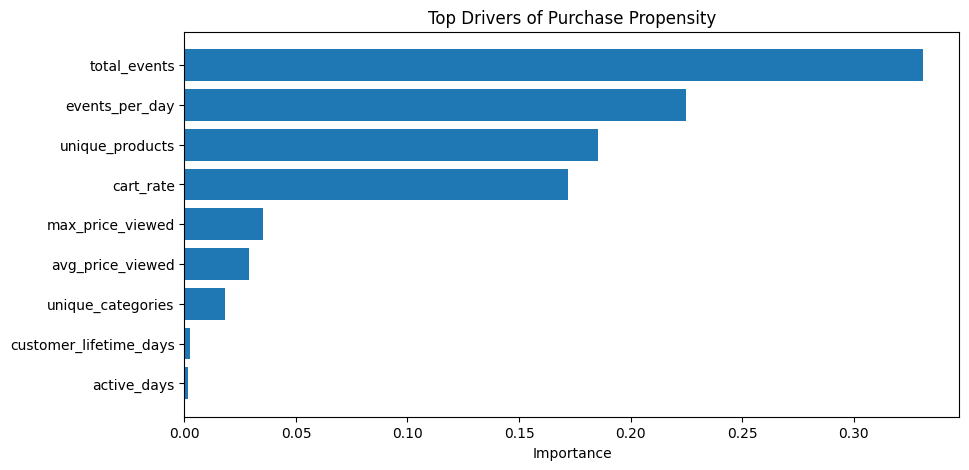

,feature,importance
0,total_events,0.330951
7,events_per_day,0.224751
2,unique_products,0.185243
8,cart_rate,0.172092
5,max_price_viewed,0.035372
4,avg_price_viewed,0.029154
3,unique_categories,0.018095
6,customer_lifetime_days,0.002650
1,active_days,0.001692


In [19]:
# ===============================
# 5. FEATURE IMPORTANCE
# ===============================

import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,5))
plt.barh(importance['feature'], importance['importance'])
plt.gca().invert_yaxis()
plt.title("Top Drivers of Purchase Propensity")
plt.xlabel("Importance")
plt.show()

importance

In [20]:
funnel_order = ['view', 'cart', 'purchase']

funnel = (
    df.groupby('event_type')['user_id']
    .nunique()
    .reindex(funnel_order)
    .reset_index()
)

funnel.columns = ['event_type', 'unique_users']

funnel['conversion_from_previous_step'] = funnel['unique_users'] / funnel['unique_users'].shift(1)
funnel['overall_conversion_from_view'] = funnel['unique_users'] / funnel.loc[0, 'unique_users']

funnel

,event_type,unique_users,conversion_from_previous_step,overall_conversion_from_view
0,view,40817,NaN,1.000000
1,cart,1425,0.034912,0.034912
2,purchase,2484,1.743158,0.060857


In [21]:
users_carted = df[df['event_type'] == 'cart']['user_id'].nunique()
users_purchased = df[df['event_type'] == 'purchase']['user_id'].nunique()

cart_abandonment_rate = 1 - (users_purchased / users_carted)

print("Cart Abandonment Rate:", round(cart_abandonment_rate * 100, 2), "%")

Cart Abandonment Rate: -74.32 %


In [22]:
top_categories = (
    df.groupby('category_code')['user_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

top_categories

,user_id
category_code,
electronics.smartphone,13287
electronics.clocks,1745
electronics.audio.headphone,1730
electronics.video.tv,1211
computers.notebook,1075
apparel.shoes,917
appliances.kitchen.refrigerators,914
appliances.environment.vacuum,869
appliances.kitchen.washer,854


<Axes: title={'center': 'Purchases by Hour'}, xlabel='hour'>

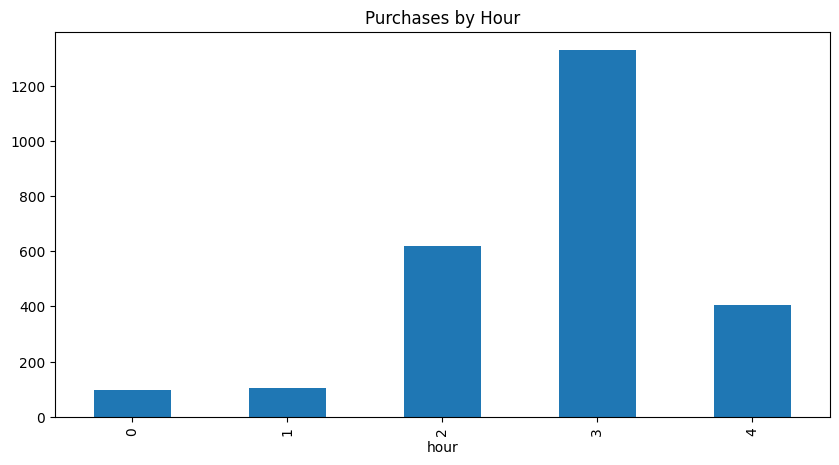

In [23]:
hourly_purchases = (
    df[df['event_type'] == 'purchase']
    .groupby('hour')['user_id']
    .nunique()
)

hourly_purchases.plot(kind='bar', figsize=(10,5), title='Purchases by Hour')

In [24]:
safe_features = [
    'total_events',
    'active_days',
    'unique_products',
    'unique_categories',
    'avg_price_viewed',
    'max_price_viewed',
    'customer_lifetime_days',
    'events_per_day',
    'cart_rate'
]

In [25]:
!pip install xgboost -q

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds = xgb_model.predict(X_test)

print(classification_report(y_test, xgb_preds))
print("XGBoost ROC AUC:", roc_auc_score(y_test, xgb_probs))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      7668
           1       0.64      0.25      0.36       497

    accuracy                           0.95      8165
   macro avg       0.80      0.62      0.67      8165
weighted avg       0.93      0.95      0.93      8165

XGBoost ROC AUC: 0.9226856968624475
